In [1]:
from simple_neural_mpc.robots import Unicycle
from simple_neural_mpc.neural_modeling.dataset import UnicycleDataset
from simple_neural_mpc.neural_modeling.dataset.datamodule import Datamodule
from simple_neural_mpc.utils import project_root
import numpy as np
from simple_neural_mpc.config.neural_config import DatasetConfig
np.set_printoptions(precision=3, suppress=True)
      
robot = Unicycle()
dataset = None if DatasetConfig.load_data else UnicycleDataset.generate_trajectory_data(robot)
datamodule = Datamodule(dataset, savedpath=f'{project_root()}/data/{DatasetConfig.name}')

batch = next(iter(datamodule.train_dataloader()))
print(batch.data.shape)
print(batch.data[0].shape)

DATA LOADED!



/home/neverorfrog/code/simple_neural_mpc/simple_neural_mpc/neural_modeling/dataset/datamodule.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.train_data = torch.l

torch.Size([64, 20, 6])
torch.Size([20, 6])


In [ ]:
from simple_neural_mpc.neural_modeling.learner.next_state_learner import NextStateLearner
from simple_neural_mpc.neural_modeling.learner.derivative_learner import DerivativeLearner
from simple_neural_mpc.neural_modeling.learner.trainer import Trainer
from simple_neural_mpc.config.neural_config import TrainerConfig

TrainerConfig.wandb_projct = "simple_neural_mpc"
learner = NextStateLearner(3, 2)
trainer = Trainer()
trainer.fit(learner, datamodule)

wandb: Currently logged in as: neverorfrog (neverorfrog-sapienza). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/neverorfrog/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/neverorfrog/code/simple_neural_mpc/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name | Type    | Params | Mode 
-----------------------------------------
0 | mlp  | MLP     | 16.7 K | train
1 | mse  | MSELoss | 0      | train
-----------------------------------------
16.7 K    Trainable params
0         Non-trainable params
16.7 K    Total params
0.067     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 547/547 [00:11<00:00, 45.94it/s, v_num=2oc9, train/imit_loss_step=0.248, train/physics_loss_step=58.90, train/loss_step=59.10, val/imit_loss_step=0.191, val/physics_loss_step=58.20, val/loss_step=58.40, val/imit_loss_epoch=0.427, val/physics_loss_epoch=58.20, val/loss_epoch=58.60, train/imit_loss_epoch=0.432, train/physics_loss_epoch=65.60, train/loss_epoch=66.10]

Metric val/loss improved. New best score: 58.620


Epoch 1: 100%|██████████| 547/547 [00:12<00:00, 44.03it/s, v_num=2oc9, train/imit_loss_step=0.163, train/physics_loss_step=51.00, train/loss_step=51.10, val/imit_loss_step=0.114, val/physics_loss_step=50.70, val/loss_step=50.80, val/imit_loss_epoch=0.324, val/physics_loss_epoch=52.20, val/loss_epoch=52.50, train/imit_loss_epoch=0.393, train/physics_loss_epoch=55.00, train/loss_epoch=55.40]

...

Epoch 69: 100%|██████████| 547/547 [00:11<00:00, 47.79it/s, v_num=2oc9, train/imit_loss_step=0.00585, train/physics_loss_step=0.895, train/loss_step=0.900, val/imit_loss_step=0.00529, val/physics_loss_step=0.887, val/loss_step=0.892, val/imit_loss_epoch=0.00701, val/physics_loss_epoch=0.890, val/loss_epoch=0.897, train/imit_loss_epoch=0.00723, train/physics_loss_epoch=0.943, train/loss_epoch=0.951]

Metric val/loss improved by 0.097 >= min_delta = 1e-06. New best score: 0.897


Epoch 70: 100%|██████████| 547/547 [00:11<00:00, 49.45it/s, v_num=2oc9, train/imit_loss_step=0.00565, train/physics_loss_step=0.902, train/loss_step=0.907, val/imit_loss_step=0.00497, val/physics_loss_step=0.861, val/loss_step=0.866, val/imit_loss_epoch=0.00667, val/physics_loss_epoch=0.828, val/loss_epoch=0.834, train/imit_loss_epoch=0.00686, train/physics_loss_epoch=0.862, train/loss_epoch=0.869]

Metric val/loss improved by 0.063 >= min_delta = 1e-06. New best score: 0.834


Epoch 71: 100%|██████████| 547/547 [00:10<00:00, 53.78it/s, v_num=2oc9, train/imit_loss_step=0.00535, train/physics_loss_step=0.752, train/loss_step=0.757, val/imit_loss_step=0.00497, val/physics_loss_step=0.861, val/loss_step=0.866, val/imit_loss_epoch=0.00667, val/physics_loss_epoch=0.828, val/loss_epoch=0.834, train/imit_loss_epoch=0.00686, train/physics_loss_epoch=0.862, train/loss_epoch=0.869]

/tmp/ipykernel_252934/3846807851.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  learner.load_state_dict(torch.load(f'{TrainerConfig.ckpt_path}/unicycle.pth'))


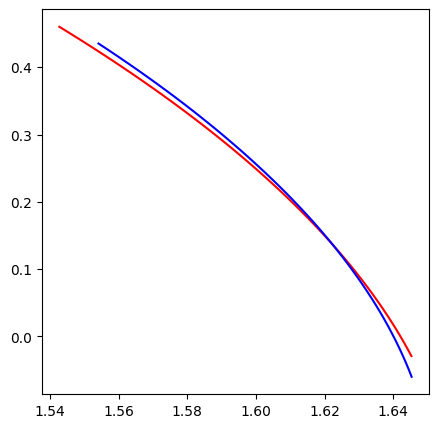

In [ ]:
import torch

learner.load_state_dict(torch.load(f'{TrainerConfig.ckpt_path}/unicycle.pth'))
test_data = UnicycleDataset.generate_test_data(robot)

learner.test_traj(test_data)